<a href="https://colab.research.google.com/github/akib-aku/South-Asia-Macro-Forecasting/blob/main/Bangladesh_Inflation_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_433428.csv to API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_433428.csv


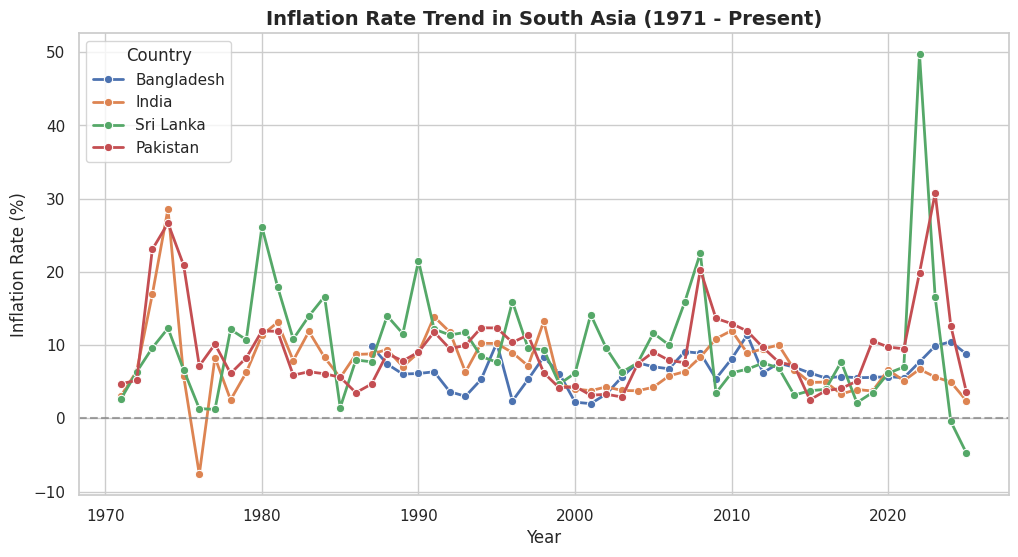

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ১. আপনার আপলোড করা ফাইলটি এখানে যুক্ত করুন
filename = 'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_433428.csv'  # <-- ফাইলের সঠিক নাম এখানে লিখবেন
df = pd.read_csv(filename, skiprows=4)

# ২. দক্ষিণ এশিয়ার প্রধান ৪টি দেশ ফিল্টার করা
countries = ['Bangladesh', 'India', 'Pakistan', 'Sri Lanka']
south_asia_df = df[df['Country Name'].isin(countries)]

# ৩. ১৯৭১ থেকে বর্তমান সময় পর্যন্ত কলামগুলো সিলেক্ট করা
year_columns = [col for col in south_asia_df.columns if col.isdigit() and int(col) >= 1971]
clean_df = south_asia_df[['Country Name'] + year_columns]

# ডেটাকে গ্রাফ আঁকার উপযোগী ফর্মেটে রূপান্তর (Melt) করা
melted_df = clean_df.melt(id_vars=['Country Name'], var_name='Year', value_name='Inflation_Rate')
melted_df['Year'] = melted_df['Year'].astype(int)

# ৪. চমৎকার একটি লাইন চার্ট বা ভিজ্যুয়ালাইজেশন তৈরি করা
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=melted_df, x='Year', y='Inflation_Rate', hue='Country Name', marker='o', linewidth=2)

plt.title('Inflation Rate Trend in South Asia (1971 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Rate (%)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.legend(title='Country')

plt.show()

In [4]:
# প্রতিটি দেশের মুদ্রাস্ফীতির মৌলিক পরিসংখ্যানিক মান বের করা (Mean, Std, Min, Max ইত্যাদি)
stats_summary = melted_df.groupby('Country Name')['Inflation_Rate'].describe()

print("--- দক্ষিণ এশিয়ার মুদ্রাস্ফীতির পরিসংখ্যানগত সারাংশ ---")
print(stats_summary)

--- দক্ষিণ এশিয়ার মুদ্রাস্ফীতির পরিসংখ্যানগত সারাংশ ---
              count      mean       std       min       25%       50%  \
Country Name                                                            
Bangladesh     39.0  6.542980  2.307105  2.007174  5.528574  6.194280   
India          55.0  7.500207  4.784007 -7.633948  4.788397  6.665657   
Pakistan       55.0  9.513715  5.953172  2.529328  5.399038  8.267047   
Sri Lanka      55.0  9.763275  8.014205 -4.763860  6.165110  7.976362   

                    75%        max  
Country Name                        
Bangladesh     7.911815  11.395165  
India          9.431234  28.598734  
Pakistan      11.835592  30.768128  
Sri Lanka     12.163614  49.721102  


In [5]:
from statsmodels.tsa.stattools import adfuller

# বাংলাদেশের মুদ্রাস্ফীতির ডেটা নিয়ে ADF টেস্ট করা
bd_series = melted_df[melted_df['Country Name'] == 'Bangladesh'].dropna().set_index('Year')['Inflation_Rate']

def run_adf_test(series, country_name):
    result = adfuller(series)
    print(f'--- ADF Test Result for {country_name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("결과 (Result): ডেটাটি Stationary (p-value < 0.05)")
    else:
        print("결과 (Result): ডেটাটি Non-Stationary (p-value >= 0.05). Differencing লাগবে।")
    print("\n")

run_adf_test(bd_series, 'Bangladesh')

--- ADF Test Result for Bangladesh ---
ADF Statistic: -2.0205
p-value: 0.2777
결과 (Result): ডেটাটি Non-Stationary (p-value >= 0.05). Differencing লাগবে।




/tmp/ipykernel_531/3826637227.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


/tmp/ipykernel_531/3826637227.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


--- ADF Test Result for Bangladesh (After First Differencing) ---
ADF Statistic: -7.6529
p-value: 0.0000
결과 (Result): ডেটাটি Stationary (p-value < 0.05)




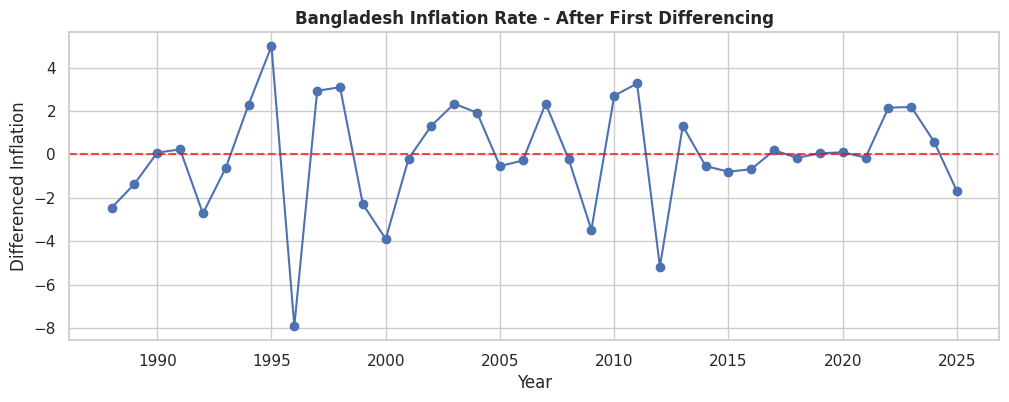

In [6]:
# ১. First Differencing করা (বর্তমান মান - আগের মান)
bd_diff = bd_series.diff().dropna()

# ২. ডিফারেন্সিং করার পর আবার ADF টেস্ট রান করা
run_adf_test(bd_diff, 'Bangladesh (After First Differencing)')

# ৩. ডিফারেন্স করা ডেটার গ্রাফ প্লট করে দেখা
plt.figure(figsize=(12, 4))
plt.plot(bd_diff, marker='o', color='b', linewidth=1.5)
plt.title('Bangladesh Inflation Rate - After First Differencing', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Differenced Inflation')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.show()

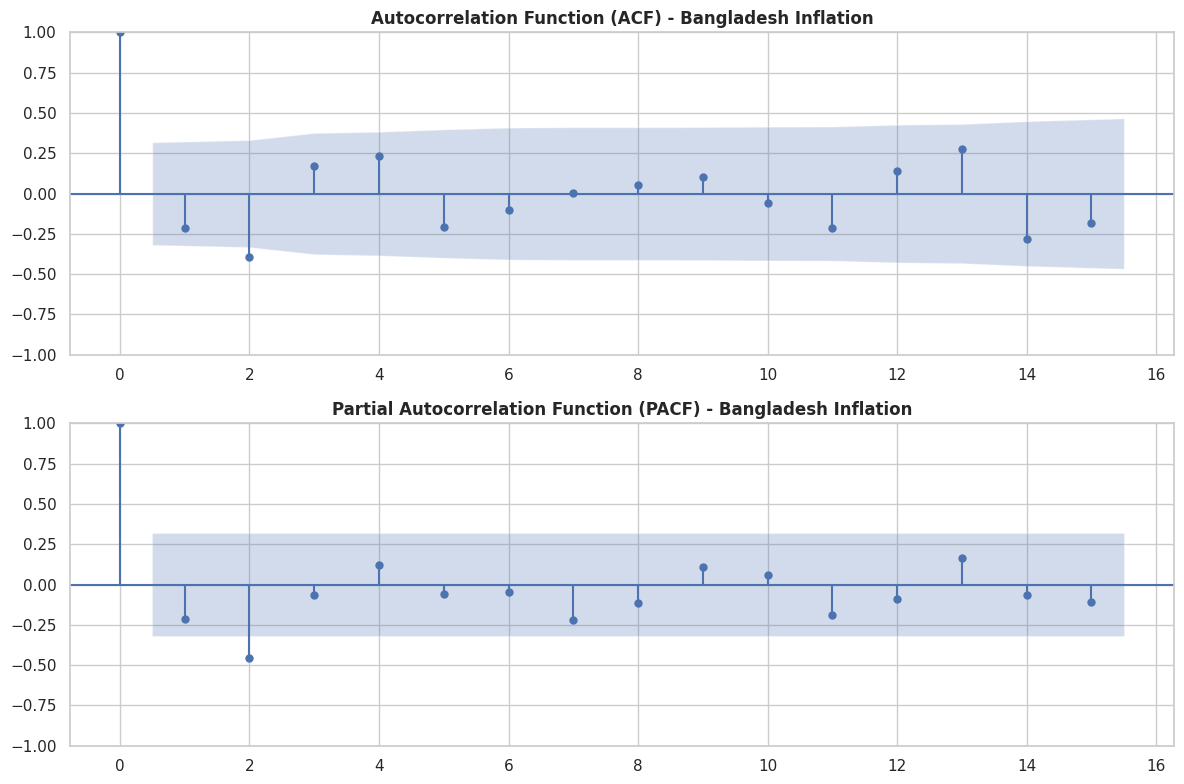

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF এবং PACF গ্রাফ আঁকা
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plot_acf(bd_diff, ax=plt.gca(), lags=15)
plt.title('Autocorrelation Function (ACF) - Bangladesh Inflation', fontsize=12, fontweight='bold')

plt.subplot(2, 1, 2)
plot_pacf(bd_diff, ax=plt.gca(), lags=15, method='ywm')
plt.title('Partial Autocorrelation Function (PACF) - Bangladesh Inflation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:         Inflation_Rate   No. Observations:                   39
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -83.927
Date:                Tue, 29 Sep 2026   AIC                            173.853
Time:                        15:56:01   BIC                            178.766
Sample:                    01-01-1987   HQIC                           175.601
                         - 01-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4369      0.226      1.931      0.053      -0.007       0.880
ma.L1         -0.9989     11.457     -0.087      0.931     -23.455      21.457
sigma2         4.5157     50.551      0.089      0.9

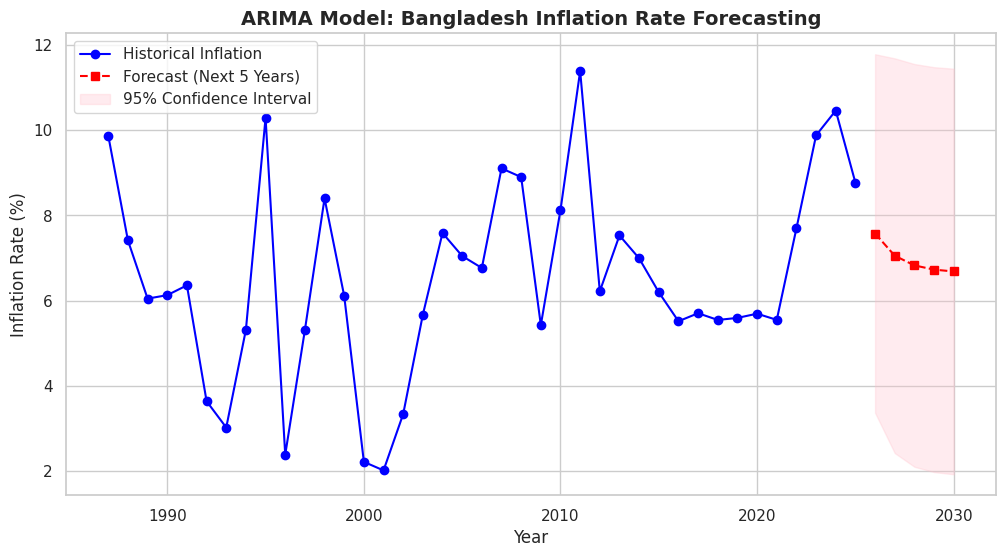

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# ১. ইনডেক্সকে সঠিক টাইম বা সিকোয়েন্স ইনডেক্সে রূপান্তর করা
bd_series_indexed = bd_series.copy()
# ইয়ারগুলোকে ডেট টাইম অবজেক্টে রূপান্তর করা যাতে মডেল বুঝতে পারে
bd_series_indexed.index = pd.to_datetime(bd_series_indexed.index, format='%Y')

# ২. ARIMA মডেল ফিট করা (সঠিক ইনডেক্স সহ)
model = ARIMA(bd_series_indexed, order=(1, 1, 1))
model_fit = model.fit()

# মডেলের সামারি দেখে নেওয়া
print(model_fit.summary())

# ৩. আগামী ৫ বছরের জন্য পূর্বাভাস (Forecast) তৈরি করা
forecast_steps = 5
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
confidence_int = forecast.conf_int()

# ৪. গ্রাফ প্লট করা
plt.figure(figsize=(12, 6))

# ঐতিহাসিক ডেটা প্লট
plt.plot(bd_series_indexed.index.year, bd_series_indexed, label='Historical Inflation', color='blue', marker='o')

# ফোরকাস্ট বা আগামী ৫ বছরের ডেটা প্লট (ভবিষ্যতের বছরগুলোর জন্য)
future_years = range(bd_series_indexed.index.year[-1] + 1, bd_series_indexed.index.year[-1] + 1 + forecast_steps)
plt.plot(future_years, forecast_mean, label='Forecast (Next 5 Years)', color='red', linestyle='--', marker='s')

# কনফিডেন্স ইন্টারভ্যাল ছায়া হিসেবে দেখানো
plt.fill_between(future_years,
                 confidence_int.iloc[:, 0],
                 confidence_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('ARIMA Model: Bangladesh Inflation Rate Forecasting', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Rate (%)', fontsize=12)
plt.legend()
plt.show()